In [1]:
import nltk
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
print("✅ NLTK data downloaded!")

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Rupayan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rupayan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rupayan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Rupayan\AppData\Roaming\nltk_data...


✅ NLTK data downloaded!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import movie_reviews
import random

# Load movie reviews dataset
documents = []
for fileid in movie_reviews.fileids():
    category = movie_reviews.categories(fileid)[0]
    text = movie_reviews.raw(fileid)
    documents.append({'text': text, 'sentiment': category})

df = pd.DataFrame(documents)
df['sentiment_label'] = df['sentiment'].map({'pos': 1, 'neg': 0})

print(f"Total reviews: {len(df)}")
print(f"\nSentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\nSample review:")
print(df['text'][0][:300])
df.head()

Matplotlib is building the font cache; this may take a moment.


Total reviews: 2000

Sentiment distribution:
sentiment
neg    1000
pos    1000
Name: count, dtype: int64

Sample review:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the


,text,sentiment,sentiment_label
0,"plot : two teen couples go to a church party ,...",neg,0
1,the happy bastard's quick movie review \ndamn ...,neg,0
2,it is movies like these that make a jaded movi...,neg,0
3,""" quest for camelot "" is warner bros . ' firs...",neg,0
4,synopsis : a mentally unstable man undergoing ...,neg,0


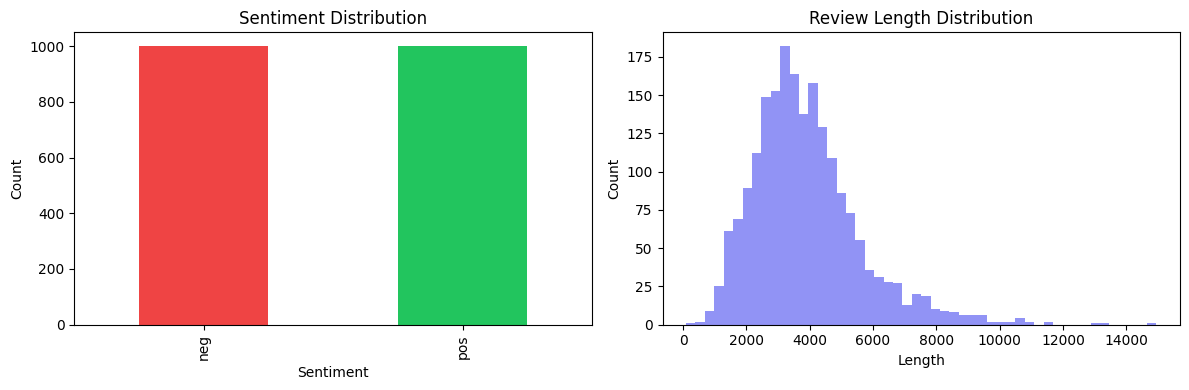

Average review length: 3893 characters


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sentiment distribution
df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#ef4444', '#22c55e'],
    title='Sentiment Distribution'
)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Review length distribution
df['text_length'] = df['text'].apply(len)
axes[1].hist(df['text_length'], bins=50, color='#6366f1', alpha=0.7)
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Average review length: {df['text_length'].mean():.0f} characters")

In [4]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print("Processing text... this takes ~30 seconds")
df['clean_text'] = df['text'].apply(preprocess_text)
print("✅ Text preprocessing done!")
print(f"\nOriginal: {df['text'][0][:200]}")
print(f"\nCleaned: {df['clean_text'][0][:200]}")

Processing text... this takes ~30 seconds
✅ Text preprocessing done!

Original: plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
w

Cleaned: plot two teen couple church party drink drive get accident one guy dy girlfriend continues see life nightmare whats deal watch movie sorta find critique mindfuck movie teen generation touch cool idea 


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import os

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment_label'],
    test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Logistic Regression
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train_vec, y_train)
lr_pred = lr_model.predict(X_test_vec)
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"✅ Logistic Regression Accuracy: {lr_accuracy:.2%}")

# Train Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vec, y_train)
rf_pred = rf_model.predict(X_test_vec)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest Accuracy: {rf_accuracy:.2%}")

# Use best model
best_model = lr_model if lr_accuracy >= rf_accuracy else rf_model
best_accuracy = max(lr_accuracy, rf_accuracy)
print(f"\n🏆 Best Model: {'Logistic Regression' if lr_accuracy >= rf_accuracy else 'Random Forest'}")
print(f"🎯 Best Accuracy: {best_accuracy:.2%}")

Training samples: 1600
Testing samples: 400

Training Logistic Regression...
✅ Logistic Regression Accuracy: 81.50%

Training Random Forest...
✅ Random Forest Accuracy: 80.00%

🏆 Best Model: Logistic Regression
🎯 Best Accuracy: 81.50%


Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81       199
    Positive       0.81      0.83      0.82       201

    accuracy                           0.81       400
   macro avg       0.82      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400



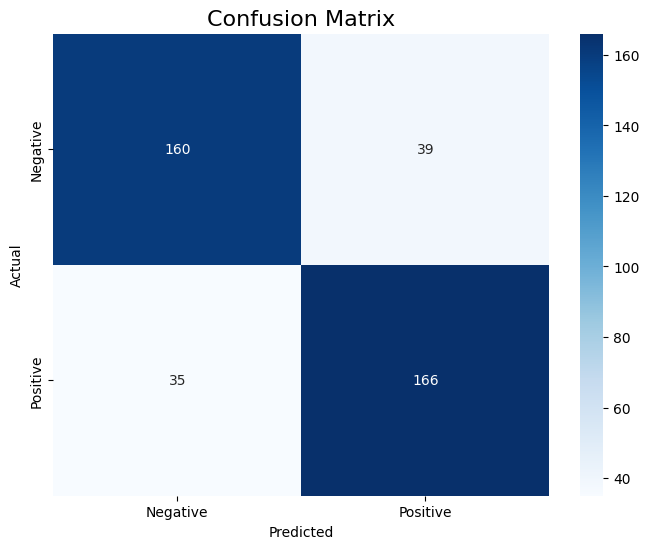

In [6]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['Negative', 'Positive']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [7]:
def predict_sentiment(text, model=lr_model, vec=vectorizer):
    cleaned = preprocess_text(text)
    vectorized = vec.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]
    
    sentiment = "POSITIVE 😊" if prediction == 1 else "NEGATIVE 😞"
    confidence = probabilities[prediction]
    
    return {
        'sentiment': sentiment,
        'confidence': f"{confidence:.2%}",
        'positive_score': f"{probabilities[1]:.2%}",
        'negative_score': f"{probabilities[0]:.2%}"
    }

# Test it!
test_texts = [
    "This movie was absolutely amazing! The acting was superb and the story was incredible.",
    "Terrible film. Complete waste of time. The worst movie I have ever seen.",
    "It was okay, nothing special but not bad either.",
    "I loved every single moment of this masterpiece!",
    "Boring and predictable. I fell asleep halfway through."
]

print("🧪 Testing our sentiment analyzer:\n")
for text in test_texts:
    result = predict_sentiment(text)
    print(f"Text: {text[:60]}...")
    print(f"Result: {result['sentiment']} (Confidence: {result['confidence']})")
    print(f"Scores → Positive: {result['positive_score']} | Negative: {result['negative_score']}")
    print("-" * 70)

🧪 Testing our sentiment analyzer:

Text: This movie was absolutely amazing! The acting was superb and...
Result: POSITIVE 😊 (Confidence: 55.54%)
Scores → Positive: 55.54% | Negative: 44.46%
----------------------------------------------------------------------
Text: Terrible film. Complete waste of time. The worst movie I hav...
Result: NEGATIVE 😞 (Confidence: 72.77%)
Scores → Positive: 27.23% | Negative: 72.77%
----------------------------------------------------------------------
Text: It was okay, nothing special but not bad either....
Result: NEGATIVE 😞 (Confidence: 81.01%)
Scores → Positive: 18.99% | Negative: 81.01%
----------------------------------------------------------------------
Text: I loved every single moment of this masterpiece!...
Result: POSITIVE 😊 (Confidence: 54.43%)
Scores → Positive: 54.43% | Negative: 45.57%
----------------------------------------------------------------------
Text: Boring and predictable. I fell asleep halfway through....
Result: NEGATIVE 😞 (C

In [8]:
# Create models directory
os.makedirs('../backend/models', exist_ok=True)

# Save model and vectorizer
with open('../backend/models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('../backend/models/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save preprocessing function
with open('../backend/models/preprocess.pkl', 'wb') as f:
    pickle.dump({'stop_words': stop_words}, f)

print("✅ Model saved to backend/models/sentiment_model.pkl")
print("✅ Vectorizer saved to backend/models/vectorizer.pkl")
print(f"\n📊 Final Model Stats:")
print(f"   Algorithm: Logistic Regression")
print(f"   Training samples: {len(X_train)}")
print(f"   Test accuracy: {lr_accuracy:.2%}")
print(f"   Features: {X_train_vec.shape[1]} TF-IDF features")

✅ Model saved to backend/models/sentiment_model.pkl
✅ Vectorizer saved to backend/models/vectorizer.pkl

📊 Final Model Stats:
   Algorithm: Logistic Regression
   Training samples: 1600
   Test accuracy: 81.50%
   Features: 10000 TF-IDF features
